Importing drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importing necessary libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

Loading the dataset

In [ ]:
# Defining column names manually
column_names = ['Class', 'age', 'menopause', 'tumor-size', 'inv-nodes', 'node-caps',
                'deg-malig', 'breast', 'breast-quad', 'irradiat']

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/breast-cancer.data', names=column_names)

# Show the first few rows
df.head()

,Class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no


Data preprocessing

In [ ]:
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

Label encoding

In [ ]:
le = LabelEncoder()
for column in df.columns:
    df[column] = le.fit_transform(df[column])

Features and Targets

In [ ]:
# Split features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Applying Principal Component Analysis

In [ ]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Step 5: Train Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 6: Prediction and Accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) * 100  # in percentage

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 69.64%


Data visualization

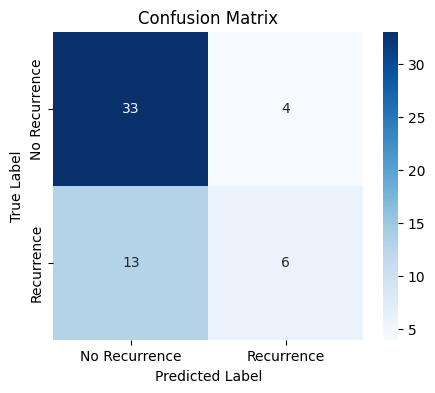

In [ ]:
# Visualization (Confusion Matrix)
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Recurrence', 'Recurrence'], yticklabels=['No Recurrence', 'Recurrence'])
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()